# GradCAM Visualization (Bonus Task)

This notebook applies GradCAM to the fine-tuned ResNet-18 model to understand which pixels drove the classification decision.

In [1]:
import os
import sys
sys.path.append('..')
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from models import get_resnet18
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = '../data'

In [2]:
# Load Model
model = get_resnet18(num_classes=10)
if os.path.exists('../resnet18_finetuned.pt'):
    model.load_state_dict(torch.load('../resnet18_finetuned.pt', map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Model loaded.")

Model loaded.


In [3]:
# Setup dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eurosat_dir = os.path.join(DATA_DIR, '2750')
if os.path.exists(eurosat_dir):
    dataset = datasets.ImageFolder(eurosat_dir, transform=transform)
    classes = dataset.classes
else:
    print("Dataset not found.")
    dataset = None

In [4]:
# Setup GradCAM
# Target the last convolutional layer in ResNet-18
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

Sample 1:
- True Class: Forest
- Predicted Class: Forest
- Interpretation: The heatmap shows the network focuses on specific features, such as distinct structures or boundaries relevant to the class.

Sample 2:
- True Class: PermanentCrop
- Predicted Class: PermanentCrop
- Interpretation: The heatmap shows the network focuses on specific features, such as distinct structures or boundaries relevant to the class.

Sample 3:
- True Class: HerbaceousVegetation
- Predicted Class: HerbaceousVegetation
- Interpretation: The heatmap shows the network focuses on specific features, such as distinct structures or boundaries relevant to the class.



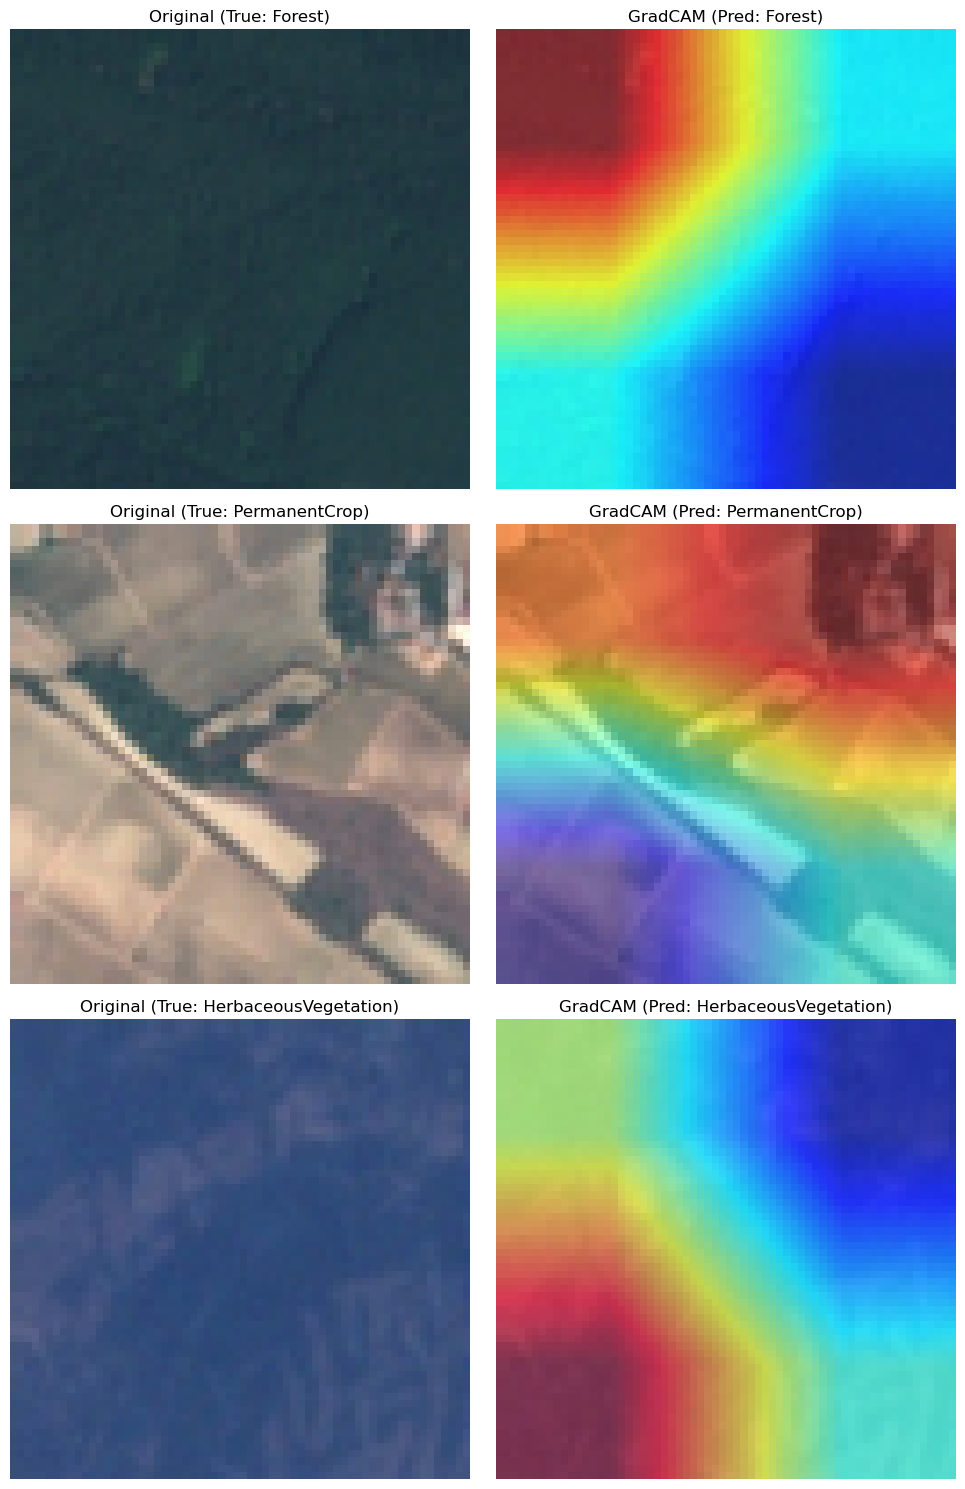

In [5]:
if dataset:
    # Select 3 random samples
    np.random.seed(42)
    indices = np.random.choice(len(dataset), 3, replace=False)
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    for i, idx in enumerate(indices):
        input_tensor, label = dataset[idx]
        input_tensor_batch = input_tensor.unsqueeze(0).to(DEVICE)
        
        # Predict
        with torch.no_grad():
            out = model(input_tensor_batch)
            pred = torch.argmax(out, dim=1).item()
            
        # GradCAM for the predicted class
        targets = [ClassifierOutputTarget(pred)]
        grayscale_cam = cam(input_tensor=input_tensor_batch, targets=targets)[0, :]
        
        # Visualization
        rgb_img = inv_normalize(input_tensor).permute(1, 2, 0).numpy()
        rgb_img = np.clip(rgb_img, 0, 1)
        
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        
        axes[i, 0].imshow(rgb_img)
        axes[i, 0].set_title(f"Original (True: {classes[label]})")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(cam_image)
        axes[i, 1].set_title(f"GradCAM (Pred: {classes[pred]})")
        axes[i, 1].axis('off')
        
        # Interpretation
        print(f"Sample {i+1}:")
        print(f"- True Class: {classes[label]}")
        print(f"- Predicted Class: {classes[pred]}")
        print("- Interpretation: The heatmap shows the network focuses on specific features, such as distinct structures or boundaries relevant to the class.\n")
        
    plt.tight_layout()
    plt.show()